In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

import plotly.io as pio
pio.renderers.default = 'notebook'

pio.renderers.default = 'iframe'

print("✅ Imports done")

✅ Imports done


In [2]:
def load_data(path='./df.csv'):
    df = pd.read_csv(path)
    print(f"  ✅ load_data            : {df.shape}")
    return df

def fix_datetime_cols(df):
    cols = ['order_purchase_timestamp','order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date',
            'order_estimated_delivery_date']
    for col in cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f"  ✅ fix_datetime_cols    : done")
    return df

def clean_nulls(df):
    df = df.dropna(subset=['order_approved_at',
                           'order_delivered_carrier_date',
                           'payment_value'])
    dim_cols = ['product_name_lenght','product_description_lenght',
                'product_photos_qty','product_length_cm',
                'product_height_cm','product_width_cm']
    for col in dim_cols:
        df[col] = df[col].fillna(df[col].median())
    df['payment_sequential']   = df['payment_sequential'].fillna(0)
    df['payment_installments'] = df['payment_installments'].fillna(0)
    df['payment_type']         = df['payment_type'].fillna('unknown')
    print(f"  ✅ clean_nulls          : {df.shape} | nulls: {df.isnull().sum().sum()}")
    return df

def add_financial_features(df):
    df['revenue']       = df['price'] + df['freight_value']
    df['cost']          = df['price'] * 0.8
    df['profit']        = df['revenue'] - df['cost']
    df['freight_ratio'] = df['freight_value'] / df['revenue']
    df['margin_%']      = (df['profit'] / df['revenue']) * 100
    print(f"  ✅ add_financial_features: done")
    return df

def add_time_features(df):
    df['year']           = df['order_purchase_timestamp'].dt.year
    df['month']          = df['order_purchase_timestamp'].dt.month
    df['day']            = df['order_purchase_timestamp'].dt.day
    df['weekday']        = df['order_purchase_timestamp'].dt.day_name()
    df['quarter']        = df['order_purchase_timestamp'].dt.quarter
    df['is_weekend']     = df['weekday'].isin(['Saturday','Sunday']).astype(int)
    df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
    print(f"  ✅ add_time_features    : done")
    return df

def add_delivery_features(df):
    df['order_delivered_customer_date'] = pd.to_datetime(
        df['order_delivered_customer_date'], errors='coerce')
    df['order_estimated_delivery_date'] = pd.to_datetime(
        df['order_estimated_delivery_date'], errors='coerce')
    df['delivery_delay_days'] = (
        df['order_delivered_customer_date'] -
        df['order_estimated_delivery_date']
    ).dt.days
    df['is_late'] = (df['delivery_delay_days'] > 0).astype(int)
    print(f"  ✅ add_delivery_features: done")
    return df

def add_cohort_features(df):
    df['Cohort_Month'] = (
        df.groupby('customer_unique_id')['purchase_month']
        .transform('min')
    )
    df['Cohort_Index'] = (
        (df['purchase_month'].dt.year  - df['Cohort_Month'].dt.year)  * 12 +
        (df['purchase_month'].dt.month - df['Cohort_Month'].dt.month)
    )
    print(f"  ✅ add_cohort_features  : done")
    return df

def run_pipeline_1(path='./df.csv'):
    print("=" * 50)
    print("  PIPELINE 1 — CLEANING & FEATURES")
    print("=" * 50)
    df = load_data(path)
    df = fix_datetime_cols(df)
    df = clean_nulls(df)
    df = add_financial_features(df)
    df = add_time_features(df)
    df = add_delivery_features(df)
    df = add_cohort_features(df)
    df.to_csv('./df_final.csv', index=False)
    print(f"  ✅ df_final.csv saved   : {df.shape}")
    print("=" * 50)
    return df

In [3]:
def build_monthly_summary(df):
    m = df.groupby('purchase_month').agg(
        total_revenue   =('revenue',            'sum'),
        total_profit    =('profit',             'sum'),
        total_orders    =('order_id',           'nunique'),
        total_customers =('customer_unique_id', 'nunique'),
        avg_delay_days  =('delivery_delay_days','mean'),
        late_orders     =('is_late',            'sum')
    ).reset_index()
    m['profit_margin_%']   = np.where(m['total_revenue'] > 0,
        (m['total_profit'] / m['total_revenue']) * 100, np.nan)
    m['AOV']               = np.where(m['total_orders'] > 0,
        m['total_revenue'] / m['total_orders'], np.nan)
    prev                   = m['total_revenue'].shift(1)
    threshold              = m['total_revenue'].median() * 0.05
    m['MoM_growth_%']      = np.where(prev >= threshold,
        ((m['total_revenue'] - prev) / prev) * 100, np.nan)
    m['MoM_growth_%']      = m['MoM_growth_%'].clip(-200, 300)
    m['Revenue_3M_MA']     = m['total_revenue'].rolling(3).mean()
    m['YoY_growth_%']      = m['total_revenue'].pct_change(12) * 100
    m['late_order_rate_%'] = (m['late_orders'] / m['total_orders']) * 100
    m = m.sort_values('purchase_month').reset_index(drop=True)
    print(f"  ✅ build_monthly_summary   : {m.shape}")
    return m

def build_category_summary(df):
    c = df.groupby('product_category_name').agg(
        total_revenue     =('revenue',           'sum'),
        total_profit      =('profit',            'sum'),
        total_orders      =('order_id',          'nunique'),
        total_freight     =('freight_value',     'sum'),
        avg_price         =('price',             'mean'),
        avg_delay         =('delivery_delay_days','mean'),
        late_orders       =('is_late',           'sum')
    ).reset_index()
    c['profit_margin_%']   = (c['total_profit']  / c['total_revenue']) * 100
    c['avg_order_value']   =  c['total_revenue']  / c['total_orders']
    c['freight_ratio_avg'] =  c['total_freight']  / c['total_revenue']
    c['late_rate_%']       = (c['late_orders']    / c['total_orders']) * 100
    c = c.drop(columns=['total_freight','late_orders'])
    c = c.sort_values('total_revenue', ascending=False)
    print(f"  ✅ build_category_summary  : {c.shape}")
    return c

def build_state_summary(df):
    s = df.groupby('customer_state').agg(
        total_revenue   =('revenue',            'sum'),
        total_profit    =('profit',             'sum'),
        total_orders    =('order_id',           'nunique'),
        total_customers =('customer_unique_id', 'nunique'),
        total_freight   =('freight_value',      'sum'),
        avg_delay       =('delivery_delay_days','mean'),
        late_orders     =('is_late',            'sum')
    ).reset_index()
    s['profit_margin_%'] = (s['total_profit']  / s['total_revenue']) * 100
    s['AOV']             =  s['total_revenue']  / s['total_orders']
    s['freight_ratio']   =  s['total_freight']  / s['total_revenue']
    s['late_rate_%']     = (s['late_orders']    / s['total_orders']) * 100
    s = s.drop(columns=['total_freight','late_orders'])
    s = s.sort_values('total_revenue', ascending=False)
    print(f"  ✅ build_state_summary     : {s.shape}")
    return s

def build_rfm_table(df):
    analysis_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
    rfm = df.groupby('customer_unique_id').agg(
        Recency  =('order_purchase_timestamp', lambda x: (analysis_date - x.max()).days),
        Frequency=('order_id',                 'nunique'),
        Monetary =('revenue',                  'sum'),
        Profit   =('profit',                   'sum'),
        Avg_Delay=('delivery_delay_days',      'mean')
    ).reset_index()
    rfm['R'] = pd.qcut(rfm['Recency'],  4, labels=[4,3,2,1], duplicates='drop')
    rfm['F'] = pd.cut(rfm['Frequency'], bins=[0,1,2,3,100],  labels=[1,2,3,4])
    rfm['M'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4], duplicates='drop')
    def segment(row):
        r,f,m = int(row['R']),int(row['F']),int(row['M'])
        if r>=3 and f>=3 and m>=3: return 'Champions'
        elif r>=3 and f>=2:        return 'Loyal'
        elif r>=3 and f<=1:        return 'New Customers'
        elif r==2 and f>=2:        return 'At Risk'
        else:                      return 'Lost'
    rfm['Segment'] = rfm.apply(segment, axis=1)
    rfm['CLV']     = rfm['Monetary'] * rfm['Frequency']
    rfm['churned'] = (rfm['Frequency'] == 1).astype(int)
    print(f"  ✅ build_rfm_table         : {rfm.shape}")
    return rfm

def build_segment_summary(rfm):
    seg = rfm.groupby('Segment').agg(
        Customer_Count=('customer_unique_id','count'),
        Total_Revenue =('Monetary',          'sum'),
        Total_Profit  =('Profit',            'sum'),
        Avg_Frequency =('Frequency',         'mean'),
        Avg_CLV       =('CLV',               'mean'),
        Churn_Rate    =('churned',           'mean')
    ).reset_index()
    seg['Profit_Margin_%'] = (seg['Total_Profit'] / seg['Total_Revenue']) * 100
    seg['Churn_Rate_%']    =  seg['Churn_Rate']   * 100
    seg = seg.drop(columns='Churn_Rate')
    print(f"  ✅ build_segment_summary   : {seg.shape}")
    return seg

def build_clv_table(rfm):
    clv = rfm[['customer_unique_id','Monetary',
               'Frequency','Recency','CLV','Segment']].copy()
    clv = clv.sort_values('CLV', ascending=False)
    print(f"  ✅ build_clv_table         : {clv.shape}")
    return clv

def build_pareto_table(rfm):
    p = rfm.sort_values('Monetary', ascending=False).copy()
    p['cumulative_revenue']    = p['Monetary'].cumsum()
    p['cumulative_revenue_%']  = p['cumulative_revenue'] / p['Monetary'].sum() * 100
    p['cumulative_customer_%'] = np.arange(1, len(p)+1) / len(p) * 100
    print(f"  ✅ build_pareto_table      : {p.shape}")
    return p

def save_all_tables(monthly, category, state, segment, clv):
    monthly.to_csv('./monthly_performance_summary.csv',  index=False, float_format='%.2f')
    category.to_csv('./category_performance_summary.csv',index=False, float_format='%.2f')
    state.to_csv('./state_performance_summary.csv',      index=False, float_format='%.2f')
    segment.to_csv('./segment_summary.csv',              index=False, float_format='%.2f')
    clv.to_csv('./clv_summary.csv',                      index=False, float_format='%.2f')
    print(f"  ✅ All 5 CSVs saved!")

def run_pipeline_2(df):
    print("=" * 50)
    print("  PIPELINE 2 — TABLE GENERATION")
    print("=" * 50)
    monthly  = build_monthly_summary(df)
    category = build_category_summary(df)
    state    = build_state_summary(df)
    rfm      = build_rfm_table(df)
    segment  = build_segment_summary(rfm)
    clv      = build_clv_table(rfm)
    pareto   = build_pareto_table(rfm)
    save_all_tables(monthly, category, state, segment, clv)
    print("=" * 50)
    return monthly, category, state, rfm, segment, clv, pareto

In [4]:
def p3_revenue_profit_trend(mc):
    fig, ax1 = plt.subplots(figsize=(14,5))
    ax1.plot(mc['purchase_month'], mc['total_revenue'],
             color='steelblue', linewidth=2.5, marker='o', markersize=4, label='Revenue')
    ax1.plot(mc['purchase_month'], mc['total_profit'],
             color='green', linewidth=2, marker='s', markersize=4, label='Profit')
    ax1.fill_between(mc['purchase_month'], mc['total_revenue'], alpha=0.08, color='steelblue')
    ax2 = ax1.twinx()
    ax2.bar(mc['purchase_month'], mc['MoM_growth_%'],
            alpha=0.2, color='orange', width=20, label='MoM %')
    ax2.set_ylabel('MoM Growth %', color='orange')
    ax1.set_title('Monthly Revenue & Profit Trend', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Amount (BRL)')
    lines1,labels1 = ax1.get_legend_handles_labels()
    lines2,labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def p3_orders_aov(mc):
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    axes[0].plot(mc['purchase_month'], mc['total_orders'],
                 color='darkorange', linewidth=2.5, marker='o', markersize=4)
    axes[0].fill_between(mc['purchase_month'], mc['total_orders'], alpha=0.08, color='darkorange')
    axes[0].set_title('Monthly Orders Trend', fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    axes[1].plot(mc['purchase_month'], mc['AOV'],
                 color='purple', linewidth=2.5, marker='o', markersize=4)
    axes[1].axhline(y=mc['AOV'].mean(), color='red', linestyle='--',
                    label=f'Avg: R${mc["AOV"].mean():.0f}')
    axes[1].set_title('Monthly AOV Trend', fontweight='bold')
    axes[1].legend()
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

def p3_revenue_margin_dual(mc):
    fig, ax1 = plt.subplots(figsize=(14,5))
    ax1.plot(mc['purchase_month'], mc['total_revenue'],
             color='steelblue', linewidth=2.5, marker='o', markersize=4, label='Revenue')
    ax1.fill_between(mc['purchase_month'], mc['total_revenue'], alpha=0.08, color='steelblue')
    ax1.set_ylabel('Revenue (BRL)', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    ax2 = ax1.twinx()
    ax2.plot(mc['purchase_month'], mc['profit_margin_%'],
             color='red', linewidth=2, marker='s', markersize=4,
             linestyle='--', label='Margin %')
    ax2.axhline(y=mc['profit_margin_%'].mean(), color='orange',
                linestyle=':', label=f'Avg: {mc["profit_margin_%"].mean():.1f}%')
    ax2.set_ylabel('Margin %', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax1.set_title('Revenue vs Profit Margin\n(Revenue UP + Margin DOWN = Cost Issue)',
                  fontsize=14, fontweight='bold')
    lines1,labels1 = ax1.get_legend_handles_labels()
    lines2,labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def p3_late_orders(mc):
    fig, ax = plt.subplots(figsize=(14,5))
    ax.bar(mc['purchase_month'], mc['late_order_rate_%'],
           color='salmon', width=20)
    ax.axhline(y=mc['late_order_rate_%'].mean(), color='red',
               linestyle='--', label=f'Avg: {mc["late_order_rate_%"].mean():.1f}%')
    ax.set_title('Monthly Late Order Rate %', fontsize=14, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Late Order Rate %')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def p3_quarterly_revenue(df):
    q = df.groupby(['year','quarter'])['revenue'].sum().reset_index()
    q['label'] = 'Q' + q['quarter'].astype(str) + '-' + q['year'].astype(str)
    fig, ax = plt.subplots(figsize=(14,5))
    bars = ax.bar(q['label'], q['revenue'], color='steelblue', edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+5000,
                f'R${h/1e6:.1f}M', ha='center', fontsize=8)
    ax.set_title('Quarterly Revenue', fontsize=14, fontweight='bold')
    ax.set_ylabel('Revenue (BRL)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def p3_weekday_revenue(df):
    order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    wd = df.groupby('weekday')['revenue'].sum().reindex(order)
    fig, ax = plt.subplots(figsize=(10,5))
    bars = ax.bar(wd.index, wd.values,
                  color=['salmon' if d in ['Saturday','Sunday'] else 'steelblue'
                         for d in wd.index])
    ax.set_title('Revenue by Weekday\n(Red = Weekend)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Total Revenue (BRL)')
    plt.tight_layout()
    plt.show()

def p3_waterfall_monthly(mc):
    top6 = mc.nlargest(6, 'total_revenue').sort_values('purchase_month')
    values = top6['total_revenue'].values
    months = top6['purchase_month'].dt.strftime('%b-%Y').values
    running = 0
    bottoms, heights, colors = [], [], []
    for i, v in enumerate(values):
        if i == 0:
            bottoms.append(0)
            heights.append(v)
            colors.append('steelblue')
        else:
            diff = v - values[i-1]
            bottoms.append(running)
            heights.append(diff)
            colors.append('green' if diff >= 0 else 'red')
        running += heights[-1] if i == 0 else diff
    fig, ax = plt.subplots(figsize=(12,5))
    ax.bar(months, heights, bottom=bottoms, color=colors, edgecolor='white')
    ax.set_title('Waterfall — Monthly Revenue Change (Top 6 Months)',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Revenue (BRL)')
    plt.tight_layout()
    plt.show()

def run_pipeline_3(df, monthly):
    mc = monthly[monthly['total_revenue'] > 0].copy()
    mc['purchase_month'] = pd.to_datetime(mc['purchase_month'])
    print("=" * 50)
    print("  PIPELINE 3 — PERFORMANCE CHARTS")
    print("=" * 50)
    p3_revenue_profit_trend(mc)
    p3_orders_aov(mc)
    p3_revenue_margin_dual(mc)
    p3_late_orders(mc)
    p3_quarterly_revenue(df)
    p3_weekday_revenue(df)
    p3_waterfall_monthly(mc)
    print("  ✅ Pipeline 3 Done!")
    print("=" * 50)

In [5]:
def p4_top_categories(category):
    fig, axes = plt.subplots(1, 2, figsize=(16,7))
    top10_rev = category.sort_values('total_revenue', ascending=True).tail(10)
    top10_pro = category.sort_values('total_profit',  ascending=True).tail(10)
    axes[0].barh(top10_rev['product_category_name'],
                 top10_rev['total_revenue'], color='steelblue')
    axes[0].set_title('Top 10 by Revenue', fontweight='bold')
    axes[1].barh(top10_pro['product_category_name'],
                 top10_pro['total_profit'],
                 color=plt.cm.Blues([x/max(top10_pro['total_profit'].values)
                                     for x in top10_pro['total_profit'].values]))
    axes[1].set_title('Top 10 by Profit', fontweight='bold')
    plt.tight_layout()
    plt.show()

def p4_category_margin(category):
    avg = category['profit_margin_%'].mean()
    colors = ['steelblue' if x >= avg else 'salmon'
              for x in category['profit_margin_%']]
    fig, ax = plt.subplots(figsize=(12,14))
    ax.barh(category['product_category_name'],
            category['profit_margin_%'], color=colors)
    ax.axvline(x=avg, color='black', linestyle='--',
               label=f'Avg: {avg:.1f}%')
    ax.set_title('Category Profit Margin %', fontsize=14, fontweight='bold')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

def p4_category_scatter(category):
    fig, ax = plt.subplots(figsize=(14,7))
    scatter = ax.scatter(
        category['total_revenue'],
        category['profit_margin_%'],
        s=category['total_orders']*0.5,
        c=category['profit_margin_%'],
        cmap='RdYlGn', alpha=0.7, edgecolors='white')
    avg_rev = category['total_revenue'].mean()
    avg_mar = category['profit_margin_%'].mean()
    ax.axvline(x=avg_rev, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=avg_mar, color='gray', linestyle='--', alpha=0.5)
    ax.text(avg_rev*1.05, avg_mar*1.05, 'STARS',      fontweight='bold', color='green')
    ax.text(avg_rev*0.01, avg_mar*1.05, 'HIDDEN GEMS',fontweight='bold', color='steelblue')
    ax.text(avg_rev*1.05, avg_mar*0.3,  'LEAKAGE',    fontweight='bold', color='red')
    ax.text(avg_rev*0.01, avg_mar*0.3,  'DANGER',     fontweight='bold', color='darkred')
    for _, row in category.nlargest(5,'total_revenue').iterrows():
        ax.annotate(row['product_category_name'],
                    xy=(row['total_revenue'], row['profit_margin_%']),
                    xytext=(10,5), textcoords='offset points', fontsize=7)
    plt.colorbar(scatter, ax=ax, label='Margin %')
    ax.set_title('Category Strategic Map', fontsize=14, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

def p4_freight_analysis(category):
    fig, axes = plt.subplots(1, 2, figsize=(16,6))
    top10_f = category.sort_values('freight_ratio_avg', ascending=True).tail(10)
    axes[0].barh(top10_f['product_category_name'],
                 top10_f['freight_ratio_avg'], color='salmon')
    axes[0].axvline(x=category['freight_ratio_avg'].mean(),
                    color='black', linestyle='--')
    axes[0].set_title('Top 10 High Freight Ratio Categories', fontweight='bold')
    axes[1].scatter(category['total_revenue'],
                    category['freight_ratio_avg'],
                    color='steelblue', alpha=0.6)
    axes[1].axhline(y=category['freight_ratio_avg'].mean(),
                    color='red', linestyle='--', label='Avg Freight Ratio')
    axes[1].set_title('Revenue vs Freight Ratio', fontweight='bold')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

def p4_state_performance(state):
    fig, axes = plt.subplots(1, 3, figsize=(18,7))
    s = state.sort_values('total_revenue', ascending=True)
    axes[0].barh(s['customer_state'], s['total_revenue'], color='steelblue')
    axes[0].set_title('Revenue by State', fontweight='bold')
    avg_m = state['profit_margin_%'].mean()
    colors = ['steelblue' if x >= avg_m else 'salmon'
              for x in s['profit_margin_%']]
    axes[1].barh(s['customer_state'], s['profit_margin_%'], color=colors)
    axes[1].axvline(x=avg_m, color='black', linestyle='--')
    axes[1].set_title('Margin % by State', fontweight='bold')
    s2 = state.sort_values('total_orders', ascending=True)
    axes[2].barh(s2['customer_state'], s2['total_orders'], color='darkorange')
    axes[2].set_title('Orders by State', fontweight='bold')
    plt.tight_layout()
    plt.show()

def p4_state_scatter(state):
    fig, ax = plt.subplots(figsize=(12,7))
    scatter = ax.scatter(
        state['total_revenue'],
        state['profit_margin_%'],
        s=state['total_orders']*0.3,
        c=state['profit_margin_%'],
        cmap='RdYlGn', alpha=0.8, edgecolors='white')
    for _, row in state.iterrows():
        ax.annotate(row['customer_state'],
                    xy=(row['total_revenue'], row['profit_margin_%']),
                    xytext=(5,5), textcoords='offset points', fontsize=8)
    plt.colorbar(scatter, ax=ax, label='Margin %')
    ax.set_title('State Strategic Map\nRevenue vs Margin', fontsize=14, fontweight='bold')
    ax.set_xlabel('Total Revenue (BRL)')
    ax.set_ylabel('Profit Margin %')
    plt.tight_layout()
    plt.show()

def p4_delivery_heatmap(df):
    delay = (df.groupby(['customer_state','month'])
             ['delivery_delay_days'].mean().unstack())
    fig, ax = plt.subplots(figsize=(14,8))
    sns.heatmap(delay, cmap='RdYlGn_r', center=0,
                linewidths=0.5, ax=ax,
                cbar_kws={'label':'Avg Delay Days'})
    ax.set_title('Delivery Delay Heatmap by State & Month',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def run_pipeline_4(df, category, state):
    print("=" * 50)
    print("  PIPELINE 4 — PRODUCT & REGIONAL CHARTS")
    print("=" * 50)
    p4_top_categories(category)
    p4_category_margin(category)
    p4_category_scatter(category)
    p4_freight_analysis(category)
    p4_state_performance(state)
    p4_state_scatter(state)
    p4_delivery_heatmap(df)
    print("  ✅ Pipeline 4 Done!")
    print("=" * 50)

In [6]:
def p5_rfm_distribution(rfm):
    seg_counts  = rfm['Segment'].value_counts().reset_index()
    seg_counts.columns = ['Segment','Count']
    colors_map  = {'Champions':'gold','Loyal':'steelblue',
                   'New Customers':'green','At Risk':'orange','Lost':'salmon'}
    fig, axes = plt.subplots(1, 2, figsize=(16,6))
    axes[0].bar(seg_counts['Segment'], seg_counts['Count'],
                color=[colors_map[s] for s in seg_counts['Segment']])
    for bar in axes[0].patches:
        axes[0].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+100,
                     f'{bar.get_height():,.0f}',
                     ha='center', fontsize=9)
    axes[0].set_title('RFM Segment Distribution', fontweight='bold')
    seg_rev = rfm.groupby('Segment')['Monetary'].sum().reset_index()
    axes[1].bar(seg_rev['Segment'], seg_rev['Monetary'],
                color=[colors_map[s] for s in seg_rev['Segment']])
    axes[1].set_title('Revenue by Segment', fontweight='bold')
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

def p5_clv_analysis(rfm):
    fig, axes = plt.subplots(1, 2, figsize=(16,6))
    axes[0].hist(rfm['Monetary'], bins=50,
                 color='steelblue', edgecolor='white')
    axes[0].axvline(x=rfm['Monetary'].mean(), color='red',
                    linestyle='--', label=f'Avg: R${rfm["Monetary"].mean():.0f}')
    axes[0].set_title('CLV Distribution', fontweight='bold')
    axes[0].legend()
    top10 = rfm.nlargest(10,'Monetary')
    axes[1].barh(top10['customer_unique_id'].str[:8],
                 top10['Monetary'], color='steelblue')
    axes[1].set_title('Top 10 Customers by CLV', fontweight='bold')
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

def p5_churn_recency(rfm):
    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    churn_counts = rfm['churned'].value_counts()
    axes[0].pie(churn_counts,
                labels=['Churned','Retained'],
                colors=['salmon','steelblue'],
                autopct='%1.1f%%', startangle=90,
                wedgeprops=dict(width=0.5))
    axes[0].set_title('Churn Distribution', fontweight='bold')
    axes[1].hist(rfm['Recency'], bins=50,
                 color='steelblue', edgecolor='white')
    axes[1].axvline(x=rfm['Recency'].mean(), color='red',
                    linestyle='--', label=f'Avg: {rfm["Recency"].mean():.0f} days')
    axes[1].set_title('Recency Distribution', fontweight='bold')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

def p5_rfm_3d_scatter(rfm):
    sample = rfm.sample(min(3000, len(rfm)), random_state=42)
    colors_map = {'Champions':'gold','Loyal':'steelblue',
                  'New Customers':'green','At Risk':'orange','Lost':'salmon'}
    fig = plt.figure(figsize=(12,8))
    ax  = fig.add_subplot(111, projection='3d')
    for seg, group in sample.groupby('Segment'):
        ax.scatter(group['Recency'], group['Frequency'], group['Monetary'],
                   label=seg, color=colors_map[seg], alpha=0.5, s=10)
    ax.set_xlabel('Recency')
    ax.set_ylabel('Frequency')
    ax.set_zlabel('Monetary')
    ax.set_title('RFM 3D Scatter by Segment', fontsize=14, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

def p5_cohort_heatmap(df):
    cohort_data = (df.groupby(['Cohort_Month','Cohort_Index'])
                   ['customer_unique_id'].nunique().reset_index())
    pivot = cohort_data.pivot_table(index='Cohort_Month',
                                    columns='Cohort_Index',
                                    values='customer_unique_id')
    retention = pivot.divide(pivot.iloc[:,0], axis=0) * 100
    fig, ax = plt.subplots(figsize=(16,8))
    sns.heatmap(retention, annot=True, fmt='.1f',
                cmap='YlOrRd_r', linewidths=0.5, ax=ax,
                cbar_kws={'label':'Retention %'})
    ax.set_title('Cohort Retention Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def p5_pareto(pareto):
    fig, ax = plt.subplots(figsize=(12,6))
    ax.plot(pareto['cumulative_customer_%'],
            pareto['cumulative_revenue_%'],
            color='steelblue', linewidth=2.5)
    ax.axhline(y=80, color='red', linestyle='--', label='80% Revenue')
    idx  = (pareto['cumulative_revenue_%'] >= 80).idxmax()
    x_80 = pareto.loc[idx,'cumulative_customer_%']
    ax.axvline(x=x_80, color='orange', linestyle='--',
               label=f'{x_80:.1f}% Customers')
    ax.annotate(f'80% revenue\nfrom {x_80:.1f}% customers',
                xy=(x_80,80), xytext=(x_80+5,60),
                fontsize=10, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))
    ax.set_title('Pareto — Revenue Concentration', fontsize=14, fontweight='bold')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

def p5_segment_profitability(rfm):
    seg = rfm.groupby('Segment').agg(
        Revenue =('Monetary', 'sum'),
        Profit  =('Profit',   'sum'),
        Count   =('customer_unique_id','count')
    ).reset_index()
    seg['Margin_%']     = (seg['Profit'] / seg['Revenue']) * 100
    seg['Revenue_per_customer'] = seg['Revenue'] / seg['Count']
    colors_map = {'Champions':'gold','Loyal':'steelblue',
                  'New Customers':'green','At Risk':'orange','Lost':'salmon'}
    fig, axes = plt.subplots(1, 2, figsize=(16,6))
    axes[0].bar(seg['Segment'], seg['Margin_%'],
                color=[colors_map[s] for s in seg['Segment']])
    axes[0].set_title('Profit Margin % by Segment', fontweight='bold')
    axes[0].set_ylabel('Margin %')
    axes[1].bar(seg['Segment'], seg['Revenue_per_customer'],
                color=[colors_map[s] for s in seg['Segment']])
    axes[1].set_title('Revenue per Customer by Segment', fontweight='bold')
    axes[1].set_ylabel('Avg Revenue (BRL)')
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

def run_pipeline_5(df, rfm, pareto):
    print("=" * 50)
    print("  PIPELINE 5 — CUSTOMER INTELLIGENCE CHARTS")
    print("=" * 50)
    p5_rfm_distribution(rfm)
    p5_clv_analysis(rfm)
    p5_churn_recency(rfm)
    p5_rfm_3d_scatter(rfm)
    p5_cohort_heatmap(df)
    p5_pareto(pareto)
    p5_segment_profitability(rfm)
    print("  ✅ Pipeline 5 Done!")
    print("=" * 50)

In [7]:
def p6_interactive_revenue(mc):
    fig = make_subplots(specs=[[{'secondary_y': True}]])
    fig.add_trace(go.Scatter(
        x=mc['purchase_month'], y=mc['total_revenue'],
        name='Revenue', line=dict(color='steelblue', width=2.5),
        fill='tozeroy', fillcolor='rgba(70,130,180,0.1)'), secondary_y=False)
    fig.add_trace(go.Scatter(
        x=mc['purchase_month'], y=mc['total_profit'],
        name='Profit', line=dict(color='green', width=2)), secondary_y=False)
    fig.add_trace(go.Bar(
        x=mc['purchase_month'], y=mc['MoM_growth_%'],
        name='MoM Growth %', marker_color='orange',
        opacity=0.3), secondary_y=True)
    fig.update_layout(title='Monthly Revenue & Profit (Interactive)',
                      template='plotly_white', hovermode='x unified')
    fig.show()

def p6_interactive_category(category):
    top20 = category.head(20)
    fig = px.bar(top20, x='total_revenue', y='product_category_name',
                 orientation='h', color='profit_margin_%',
                 color_continuous_scale='RdYlGn',
                 title='Top 20 Categories — Revenue & Margin',
                 labels={'total_revenue':'Revenue','profit_margin_%':'Margin %'})
    fig.update_layout(template='plotly_white')
    fig.show()

def p6_treemap_category(category):
    fig = px.treemap(category,
                     path=['product_category_name'],
                     values='total_revenue',
                     color='profit_margin_%',
                     color_continuous_scale='RdYlGn',
                     title='Category Revenue Treemap')
    fig.update_layout(template='plotly_white')
    fig.show()

def p6_sunburst_state_category(df):
    sc = df.groupby(['customer_state','product_category_name'])['revenue'].sum().reset_index()
    sc = sc[sc['customer_state'].isin(
        df.groupby('customer_state')['revenue'].sum().nlargest(5).index)]
    fig = px.sunburst(sc,
                      path=['customer_state','product_category_name'],
                      values='revenue',
                      title='Revenue — State → Category (Sunburst)')
    fig.update_layout(template='plotly_white')
    fig.show()

def p6_interactive_scatter(category):
    fig = px.scatter(category,
                     x='total_revenue', y='profit_margin_%',
                     size='total_orders', color='profit_margin_%',
                     color_continuous_scale='RdYlGn',
                     hover_name='product_category_name',
                     title='Category Strategic Map (Interactive)',
                     labels={'total_revenue':'Revenue',
                             'profit_margin_%':'Margin %'})
    fig.add_hline(y=category['profit_margin_%'].mean(),
                  line_dash='dash', line_color='gray')
    fig.add_vline(x=category['total_revenue'].mean(),
                  line_dash='dash', line_color='gray')
    fig.update_layout(template='plotly_white')
    fig.show()

def p6_interactive_rfm(rfm):
    sample = rfm.sample(min(5000, len(rfm)), random_state=42)
    fig = px.scatter_3d(sample,
                        x='Recency', y='Frequency', z='Monetary',
                        color='Segment', opacity=0.6,
                        title='RFM 3D Scatter (Interactive)',
                        color_discrete_map={
                            'Champions':'gold','Loyal':'steelblue',
                            'New Customers':'green','At Risk':'orange','Lost':'salmon'})
    fig.update_layout(template='plotly_white')
    fig.show()

def p6_interactive_cohort(df):
    cohort_data = (df.groupby(['Cohort_Month','Cohort_Index'])
                   ['customer_unique_id'].nunique().reset_index())
    pivot = cohort_data.pivot_table(index='Cohort_Month',
                                    columns='Cohort_Index',
                                    values='customer_unique_id')
    retention = pivot.divide(pivot.iloc[:,0], axis=0) * 100
    fig = px.imshow(retention,
                    color_continuous_scale='RdYlGn',
                    title='Cohort Retention Heatmap (Interactive)',
                    labels=dict(x='Months After Purchase',
                                y='Cohort Month',
                                color='Retention %'))
    fig.update_layout(template='plotly_white')
    fig.show()

def p6_waterfall_revenue(mc):
    top8 = mc.nlargest(8,'total_revenue').sort_values('purchase_month')
    fig = go.Figure(go.Waterfall(
        name='Revenue',
        orientation='v',
        x=top8['purchase_month'].dt.strftime('%b-%Y'),
        y=top8['total_revenue'].diff().fillna(top8['total_revenue'].iloc[0]),
        connector={'line':{'color':'rgb(63,63,63)'}},
        increasing={'marker':{'color':'green'}},
        decreasing={'marker':{'color':'red'}},
        totals={'marker':{'color':'steelblue'}}
    ))
    fig.update_layout(title='Waterfall — Monthly Revenue Change',
                      template='plotly_white')
    fig.show()

def run_pipeline_6(df, mc, category, rfm):
    print("=" * 50)
    print("  PIPELINE 6 — INTERACTIVE PLOTLY CHARTS")
    print("=" * 50)
    p6_interactive_revenue(mc)
    p6_interactive_category(category)
    p6_treemap_category(category)
    p6_sunburst_state_category(df)
    p6_interactive_scatter(category)
    p6_interactive_rfm(rfm)
    p6_interactive_cohort(df)
    p6_waterfall_revenue(mc)
    print("  ✅ Pipeline 6 Done!")
    print("=" * 50)

In [8]:
def run_pipeline_7(df, monthly, category, state, rfm):
    mc = monthly[monthly['total_revenue'] > 0].copy()
    mc['purchase_month'] = pd.to_datetime(mc['purchase_month'])

    # --- KPIs ---
    total_rev    = df['revenue'].sum()
    total_profit = df['profit'].sum()
    total_orders = df['order_id'].nunique()
    total_cust   = df['customer_unique_id'].nunique()
    avg_margin   = (total_profit / total_rev) * 100
    churn_rate   = (rfm['churned'].mean()) * 100

    print("=" * 50)
    print("  PIPELINE 7 — POWERBI STYLE DASHBOARD")
    print("=" * 50)

    # --- KPI Cards ---
    fig = go.Figure()
    kpis = [
        ('Total Revenue',  f'R${total_rev/1e6:.2f}M',  0.1),
        ('Total Profit',   f'R${total_profit/1e6:.2f}M',0.28),
        ('Total Orders',   f'{total_orders:,}',          0.46),
        ('Customers',      f'{total_cust:,}',            0.64),
        ('Avg Margin',     f'{avg_margin:.1f}%',         0.82),
    ]
    for label, value, x in kpis:
        fig.add_annotation(x=x, y=0.7, text=value,
                           font=dict(size=28, color='steelblue'),
                           showarrow=False, xref='paper', yref='paper')
        fig.add_annotation(x=x, y=0.3, text=label,
                           font=dict(size=12, color='gray'),
                           showarrow=False, xref='paper', yref='paper')
    fig.update_layout(title='Executive KPI Dashboard',
                      template='plotly_white', height=200,
                      plot_bgcolor='white', paper_bgcolor='white')
    fig.show()

    # --- Dashboard Row 1: Revenue + Category ---
    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=['Monthly Revenue Trend',
                                        'Top 10 Categories by Revenue'])
    fig.add_trace(go.Scatter(
        x=mc['purchase_month'], y=mc['total_revenue'],
        fill='tozeroy', line=dict(color='steelblue'),
        name='Revenue'), row=1, col=1)
    top10 = category.head(10).sort_values('total_revenue')
    fig.add_trace(go.Bar(
        x=top10['total_revenue'], y=top10['product_category_name'],
        orientation='h', marker_color='steelblue',
        name='Revenue'), row=1, col=2)
    fig.update_layout(template='plotly_white', height=400,
                      title='Revenue Overview', showlegend=False)
    fig.show()

    # --- Dashboard Row 2: State + Segment ---
    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=['Revenue by State',
                                        'RFM Segment Distribution'])
    s = state.sort_values('total_revenue').tail(10)
    fig.add_trace(go.Bar(
        x=s['total_revenue'], y=s['customer_state'],
        orientation='h', marker_color='darkorange',
        name='State Revenue'), row=1, col=1)
    seg_counts = rfm['Segment'].value_counts().reset_index()
    seg_counts.columns = ['Segment','Count']
    colors_map = {'Champions':'gold','Loyal':'steelblue',
                  'New Customers':'green','At Risk':'orange','Lost':'salmon'}
    fig.add_trace(go.Bar(
        x=seg_counts['Segment'], y=seg_counts['Count'],
        marker_color=[colors_map[s] for s in seg_counts['Segment']],
        name='Segments'), row=1, col=2)
    fig.update_layout(template='plotly_white', height=400,
                      title='Regional & Customer Overview', showlegend=False)
    fig.show()

    # --- Dashboard Row 3: Treemap + Scatter ---
    fig = px.treemap(category,
                     path=['product_category_name'],
                     values='total_revenue',
                     color='profit_margin_%',
                     color_continuous_scale='RdYlGn',
                     title='Category Revenue Treemap')
    fig.update_layout(template='plotly_white', height=500)
    fig.show()

    # --- Dashboard Row 4: Sunburst ---
    sc = df.groupby(['customer_state','product_category_name'])['revenue'].sum().reset_index()
    sc = sc[sc['customer_state'].isin(
        df.groupby('customer_state')['revenue'].sum().nlargest(8).index)]
    fig = px.sunburst(sc,
                      path=['customer_state','product_category_name'],
                      values='revenue',
                      title='Revenue Breakdown — State to Category')
    fig.update_layout(template='plotly_white', height=600)
    fig.show()

    # --- Dashboard Row 5: Margin + CLV ---
    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=['Margin % by State',
                                        'CLV Distribution'])
    avg_m = state['profit_margin_%'].mean()
    colors = ['green' if x >= avg_m else 'red'
              for x in state['profit_margin_%']]
    fig.add_trace(go.Bar(
        x=state['customer_state'], y=state['profit_margin_%'],
        marker_color=colors, name='Margin'), row=1, col=1)
    fig.add_trace(go.Histogram(
        x=rfm['Monetary'], nbinsx=50,
        marker_color='steelblue', name='CLV'), row=1, col=2)
    fig.update_layout(template='plotly_white', height=400,
                      title='Profitability & CLV', showlegend=False)
    fig.show()

    print("  ✅ Pipeline 7 Done!")
    print("=" * 50)

  PIPELINE 1 — CLEANING & FEATURES
  ✅ load_data            : (115030, 33)
  ✅ fix_datetime_cols    : done
  ✅ clean_nulls          : (115011, 33) | nulls: 0
  ✅ add_financial_features: done
  ✅ add_time_features    : done
  ✅ add_delivery_features: done
  ✅ add_cohort_features  : done
  ✅ df_final.csv saved   : (115011, 49)
  PIPELINE 2 — TABLE GENERATION
  ✅ build_monthly_summary   : (22, 13)
  ✅ build_category_summary  : (74, 10)
  ✅ build_state_summary     : (27, 10)
  ✅ build_rfm_table         : (93335, 12)
  ✅ build_segment_summary   : (5, 8)
  ✅ build_clv_table         : (93335, 6)
  ✅ build_pareto_table      : (93335, 15)
  ✅ All 5 CSVs saved!
  PIPELINE 3 — PERFORMANCE CHARTS


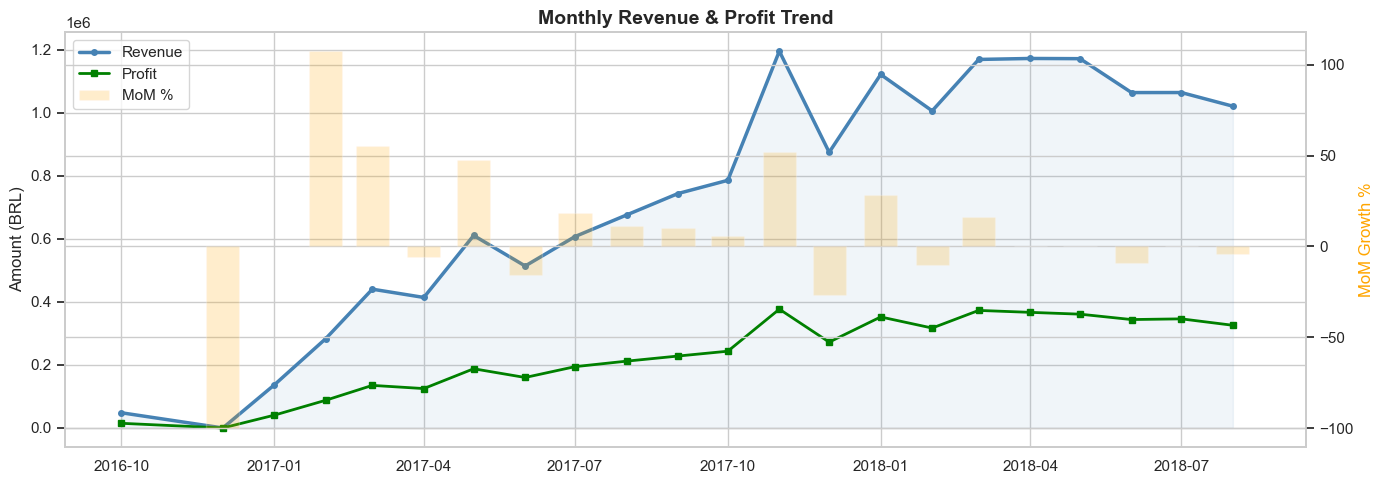

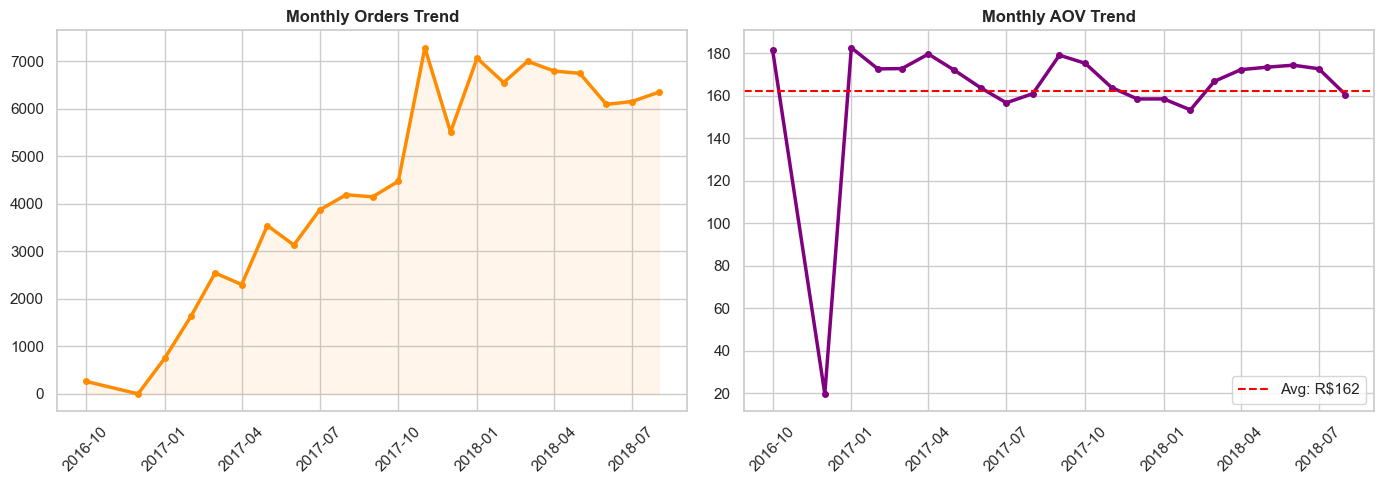

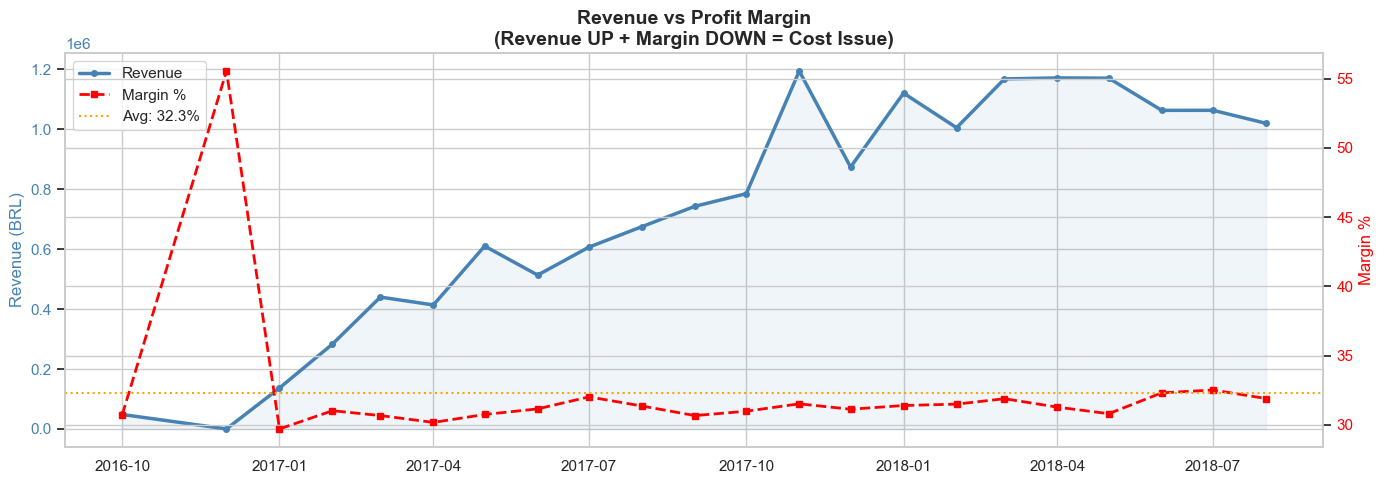

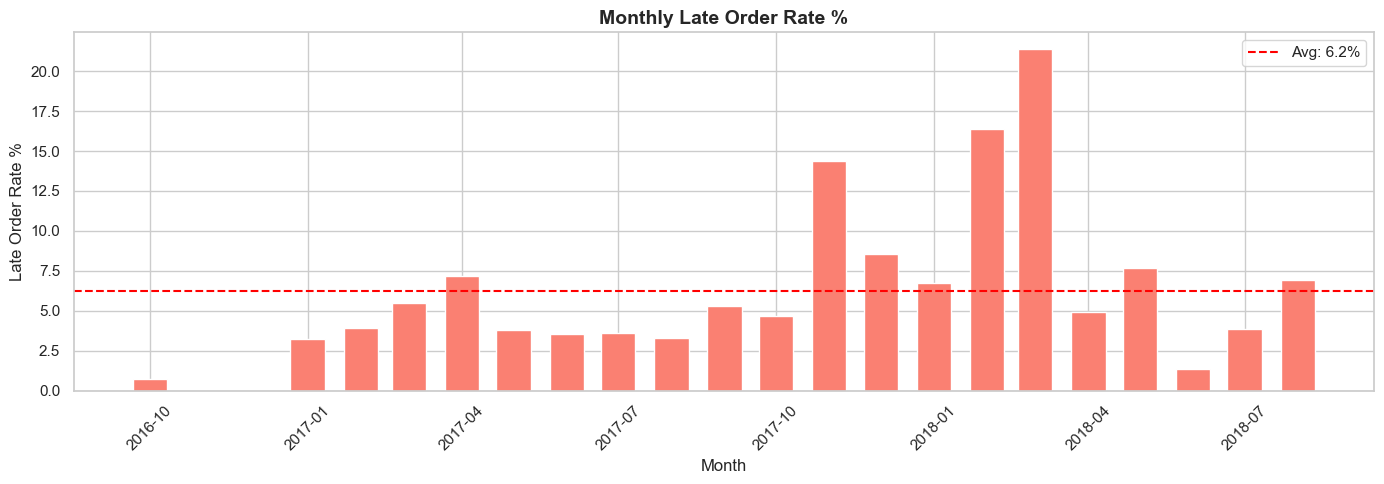

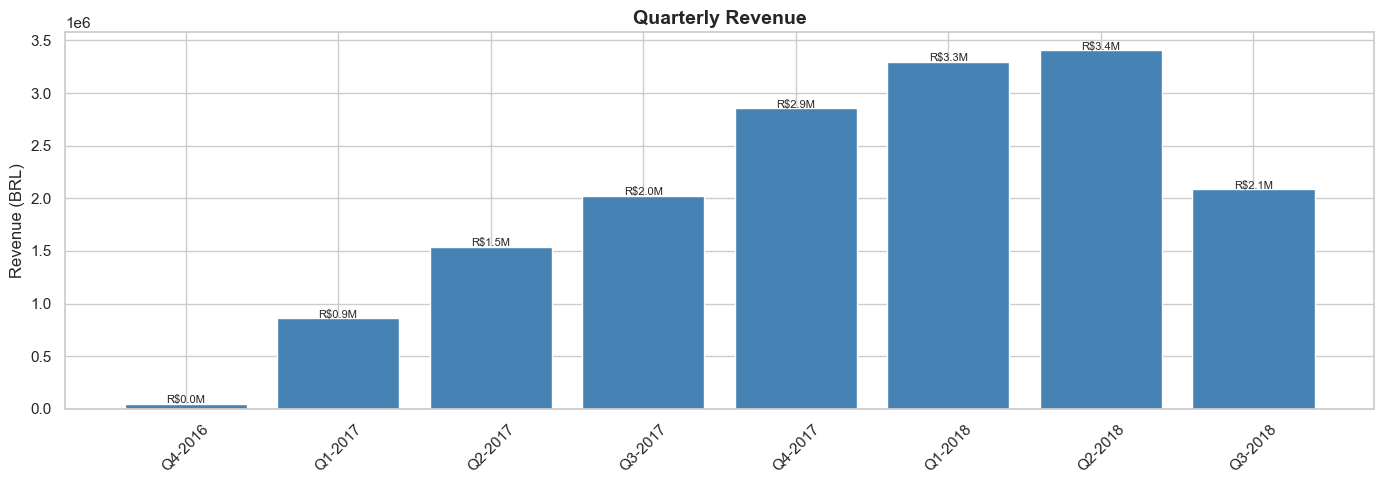

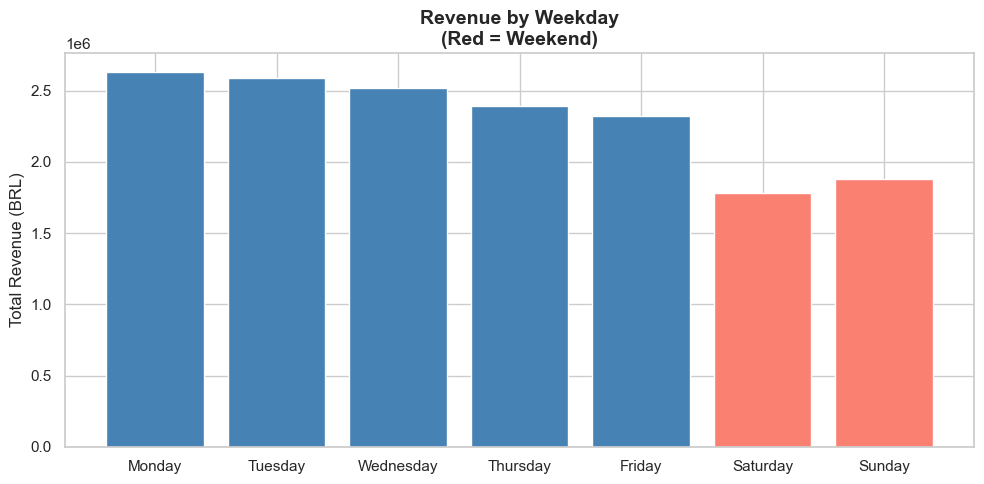

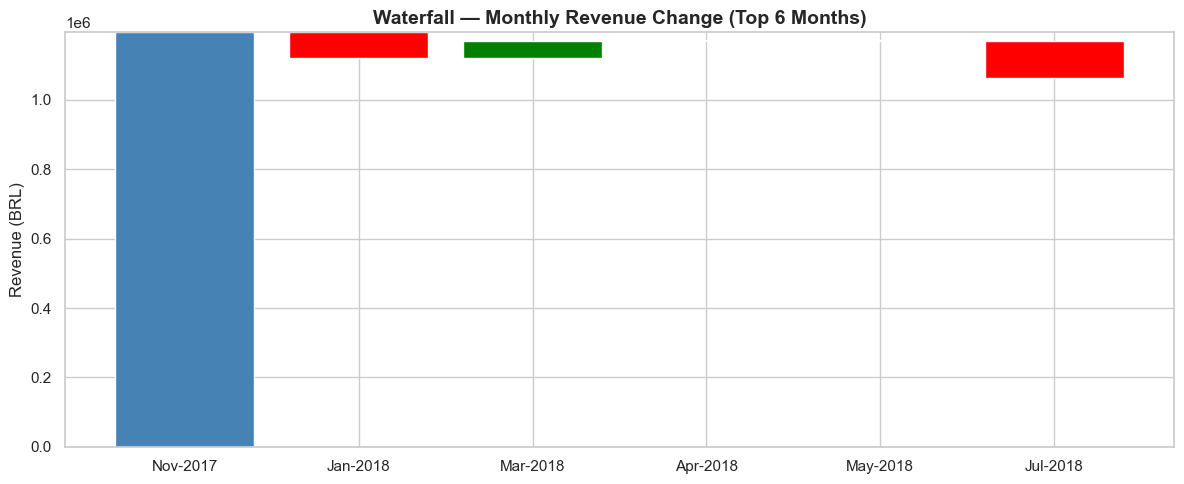

  ✅ Pipeline 3 Done!
  PIPELINE 4 — PRODUCT & REGIONAL CHARTS


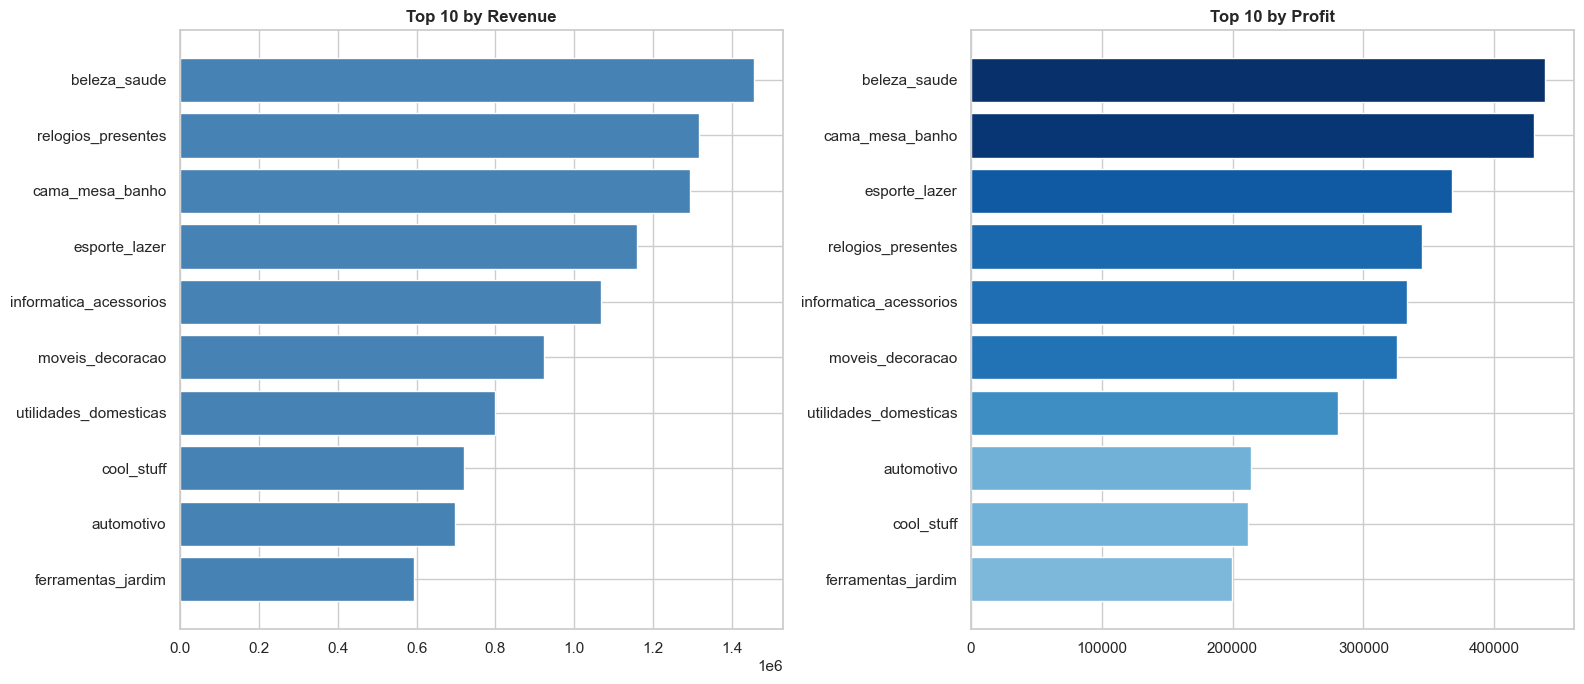

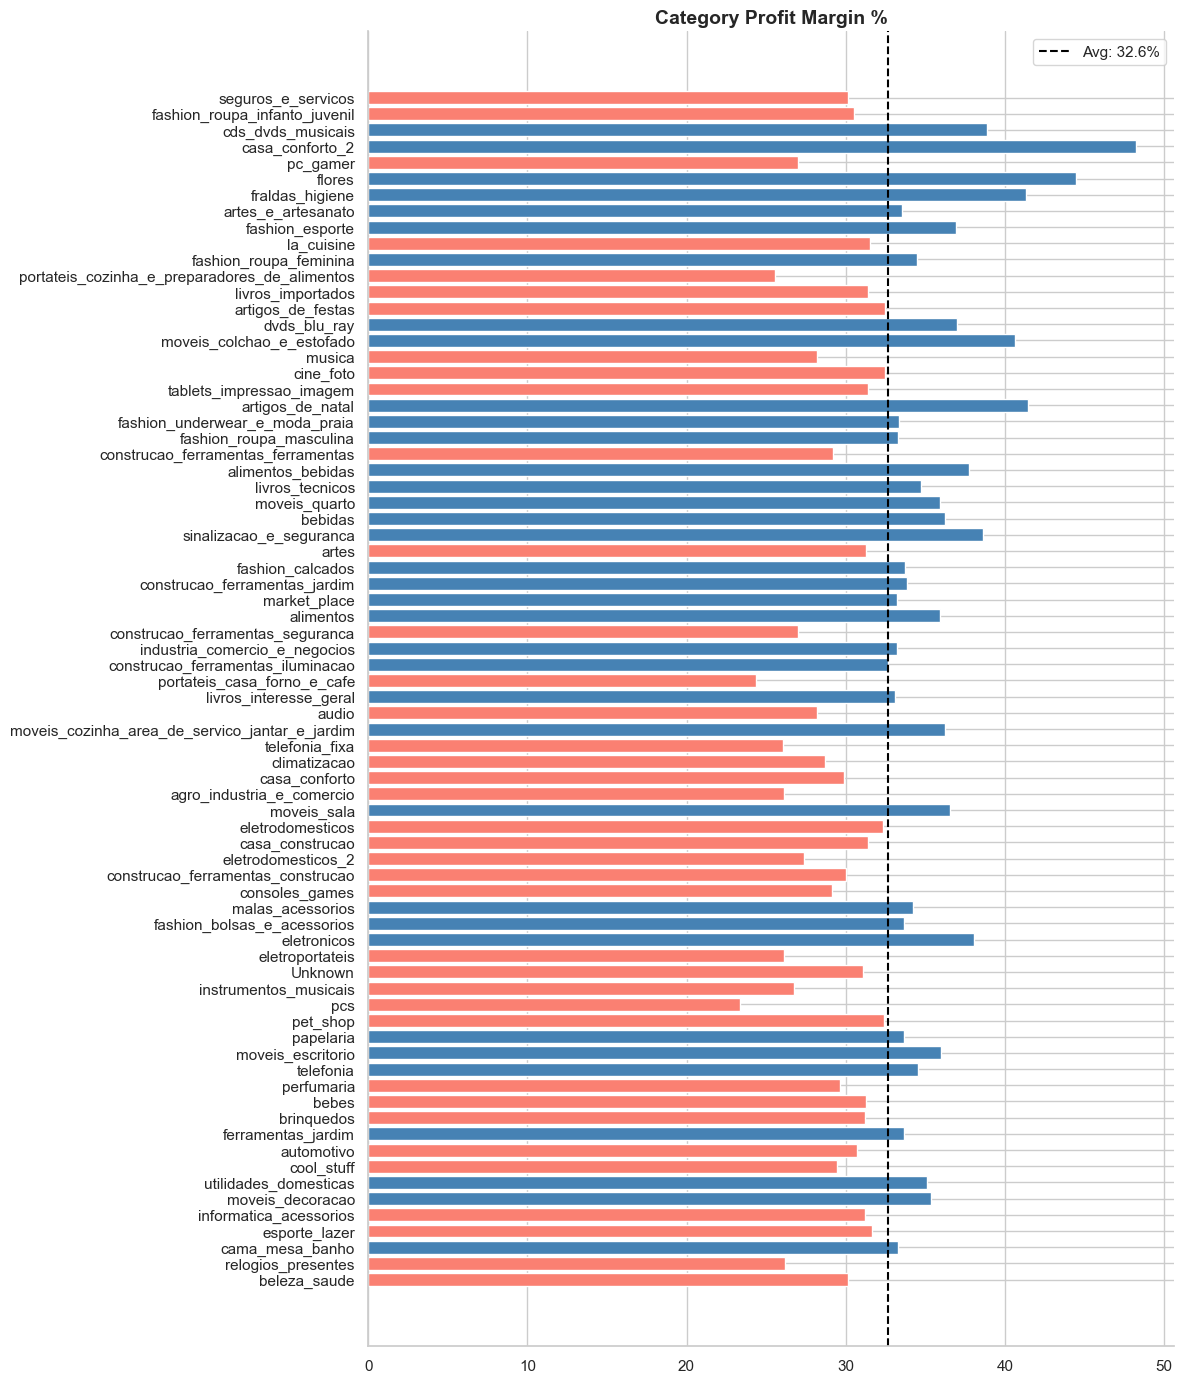

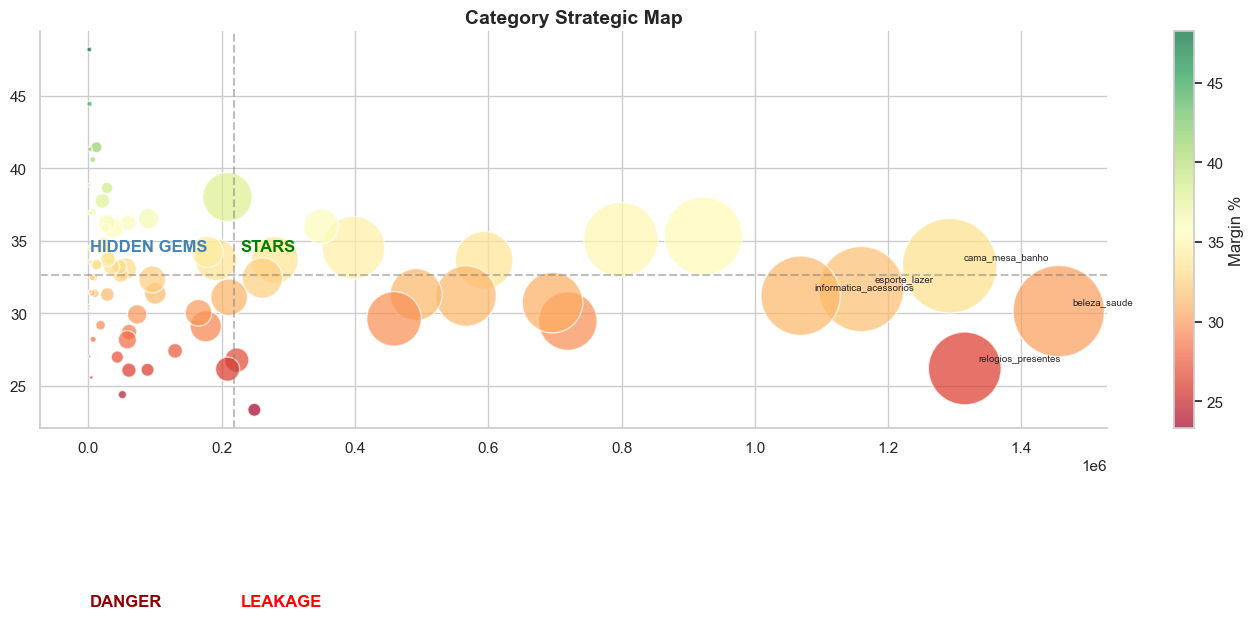

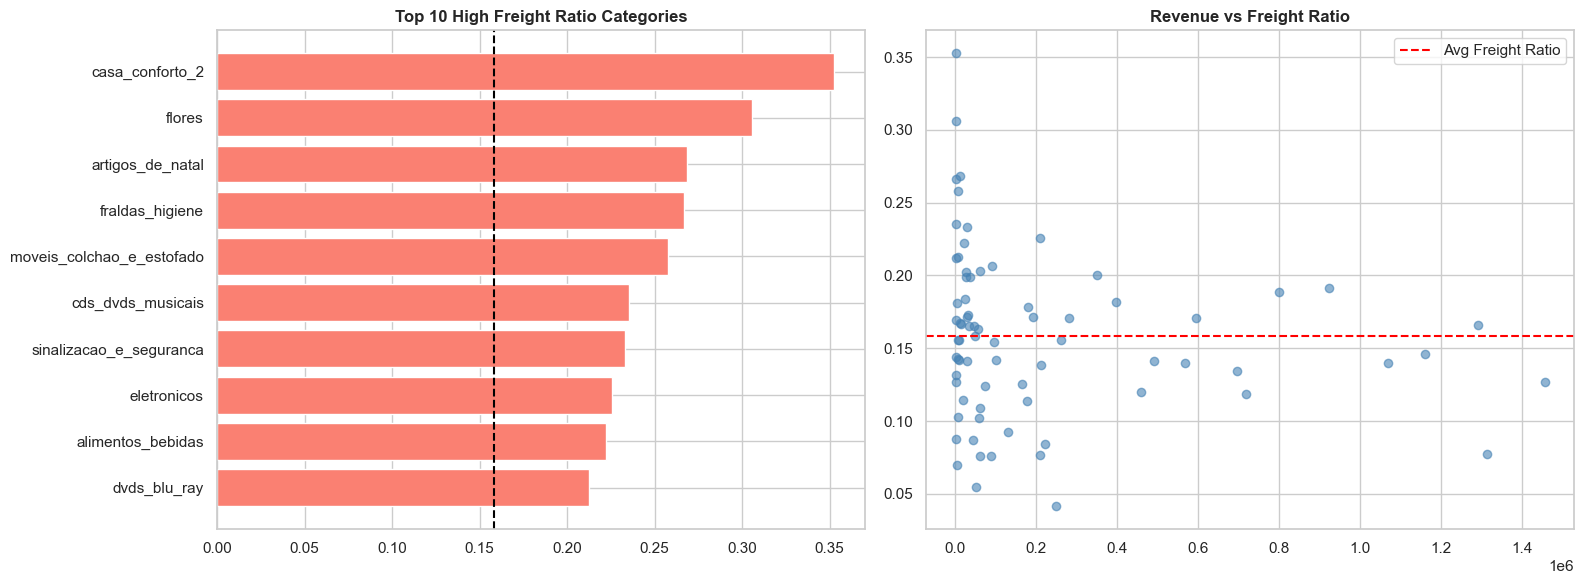

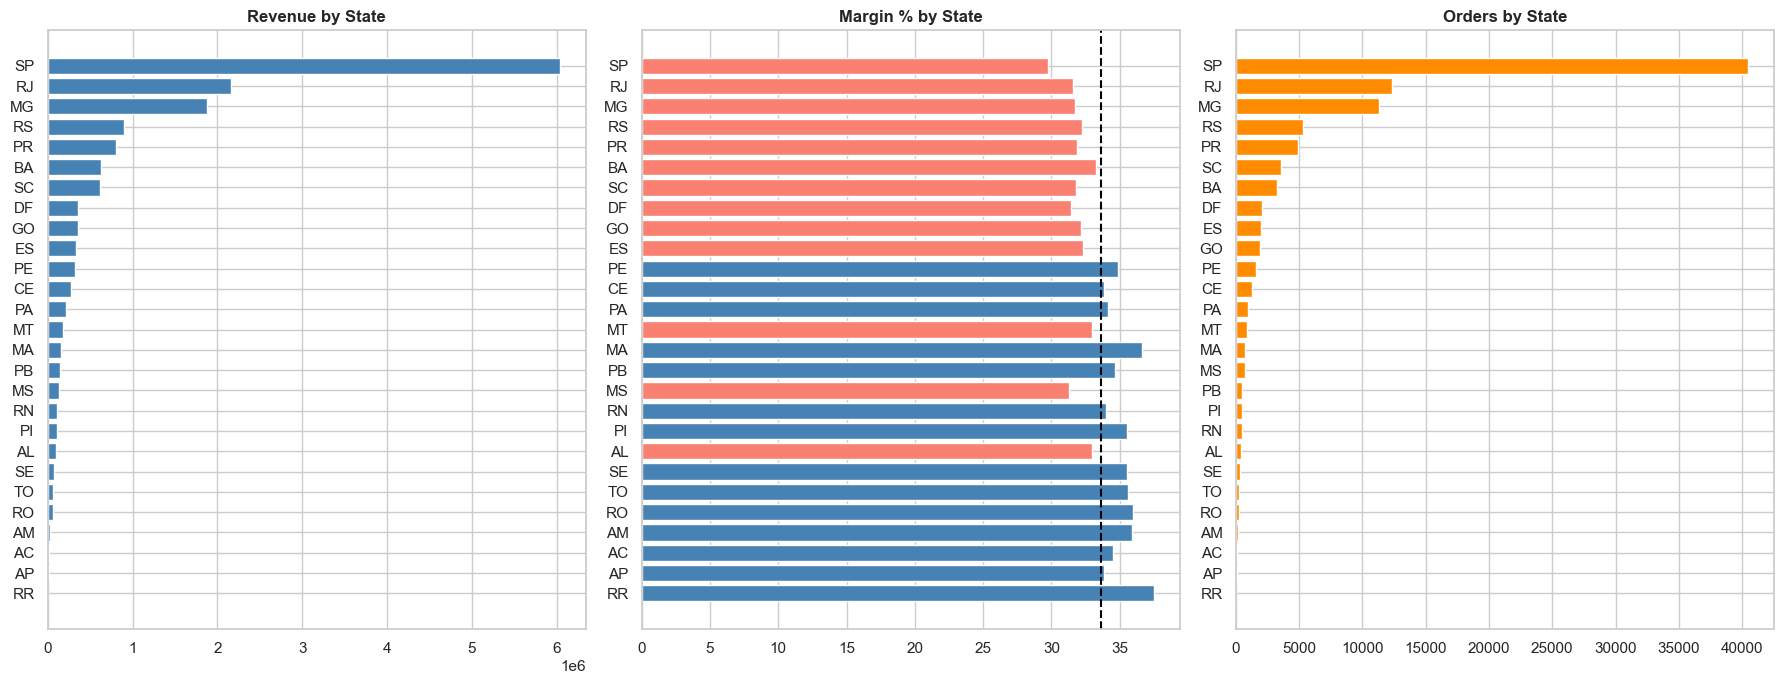

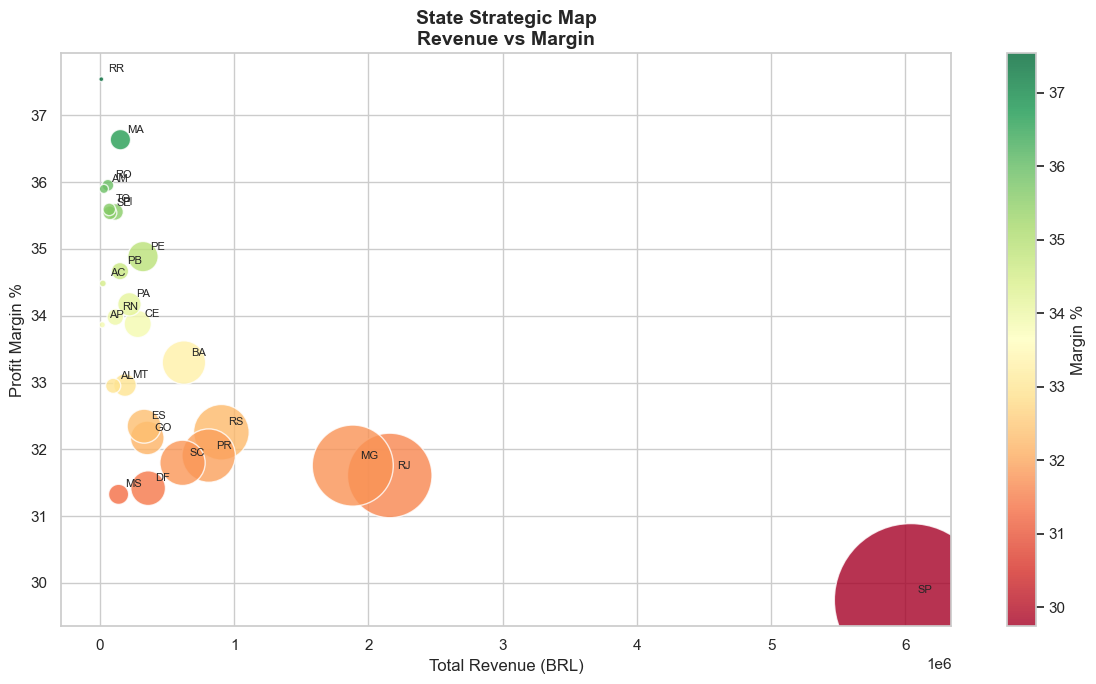

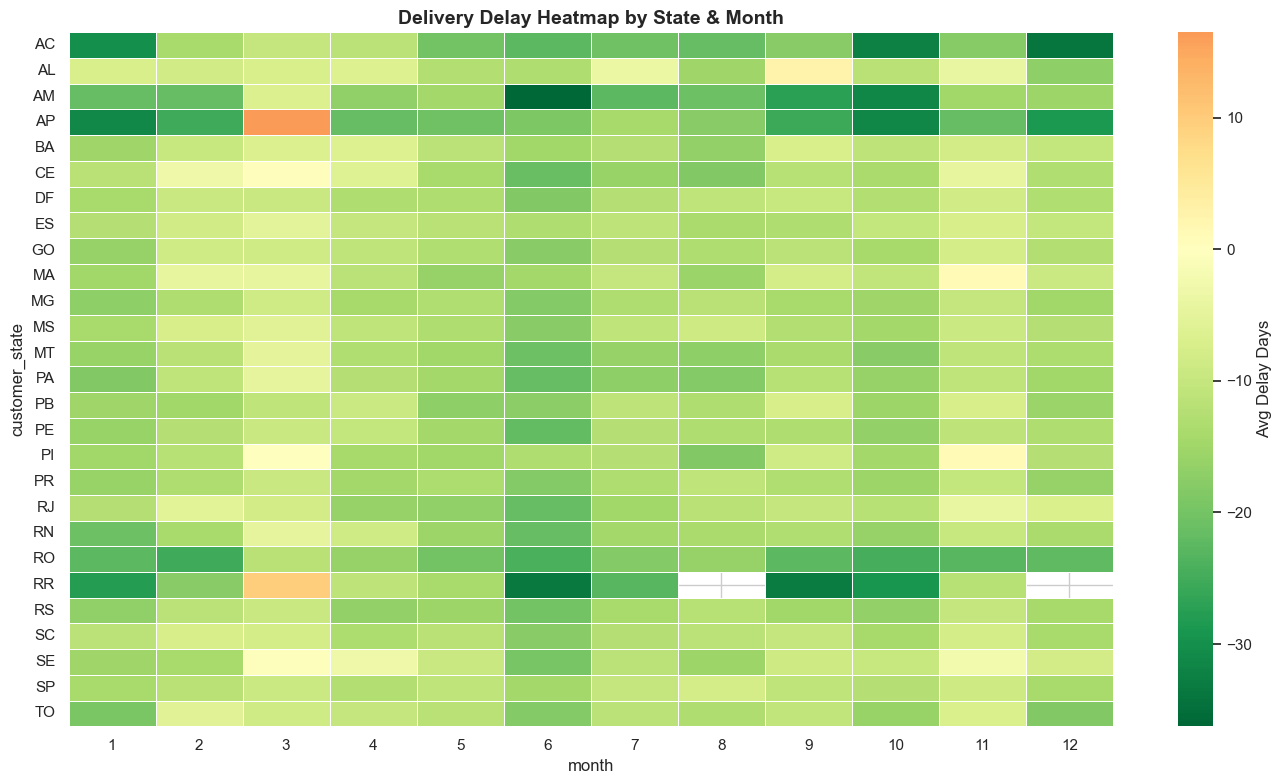

  ✅ Pipeline 4 Done!
  PIPELINE 5 — CUSTOMER INTELLIGENCE CHARTS


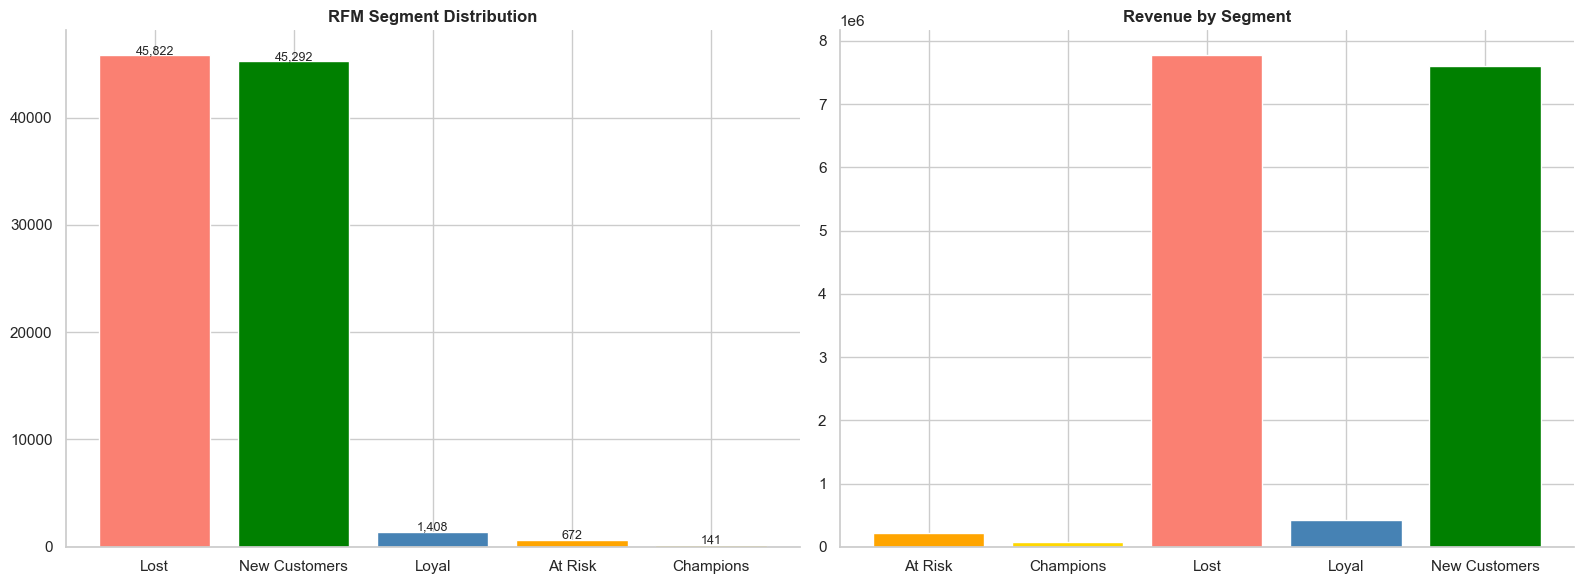

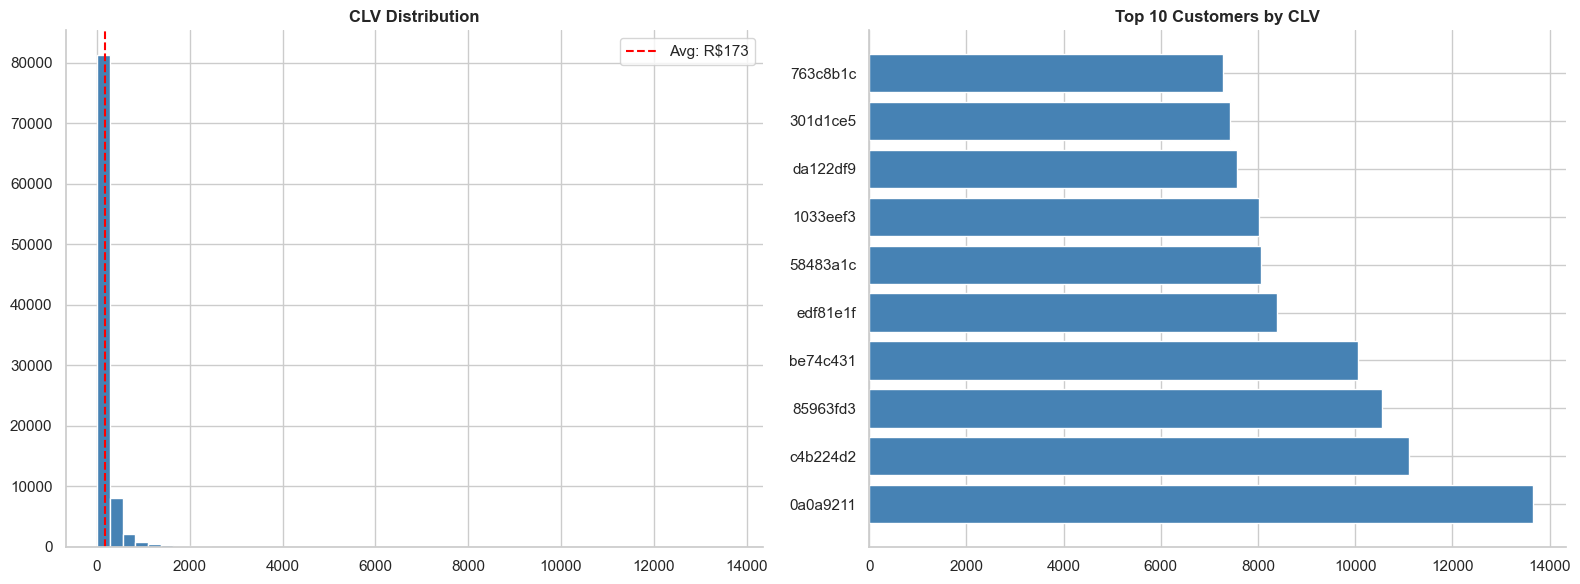

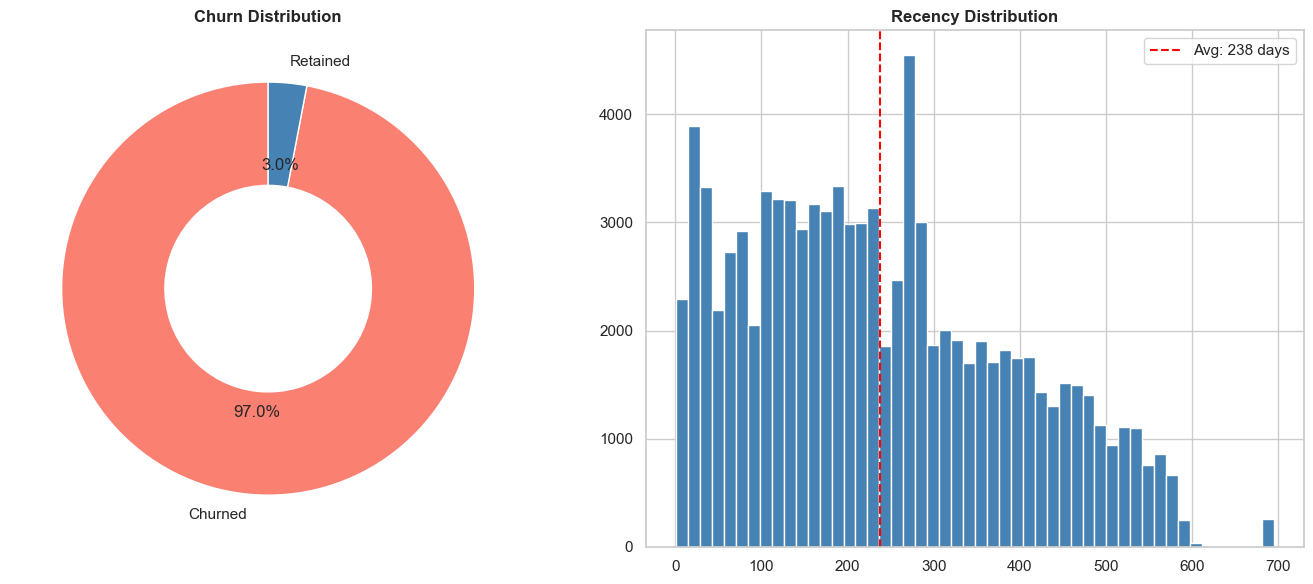

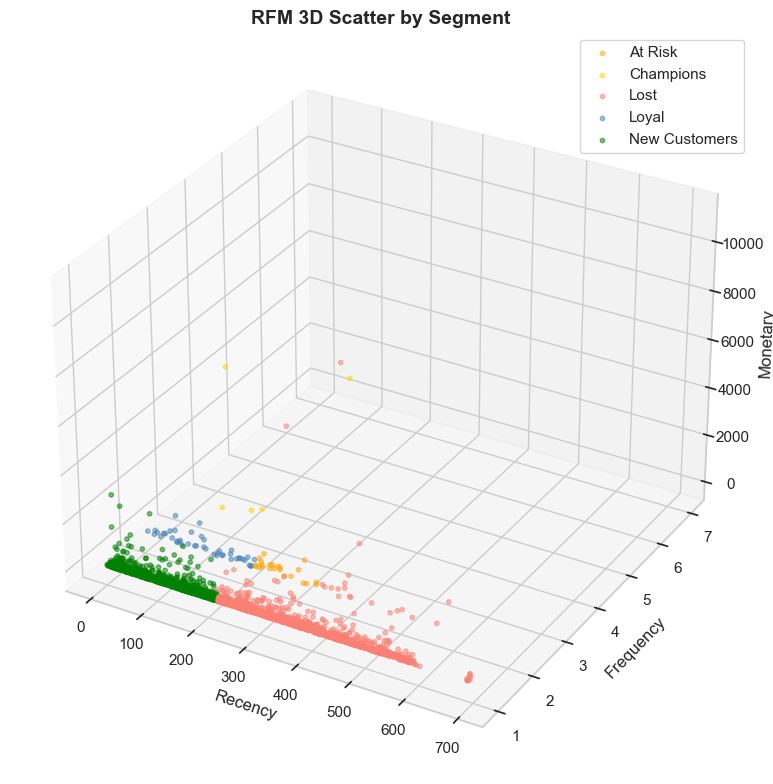

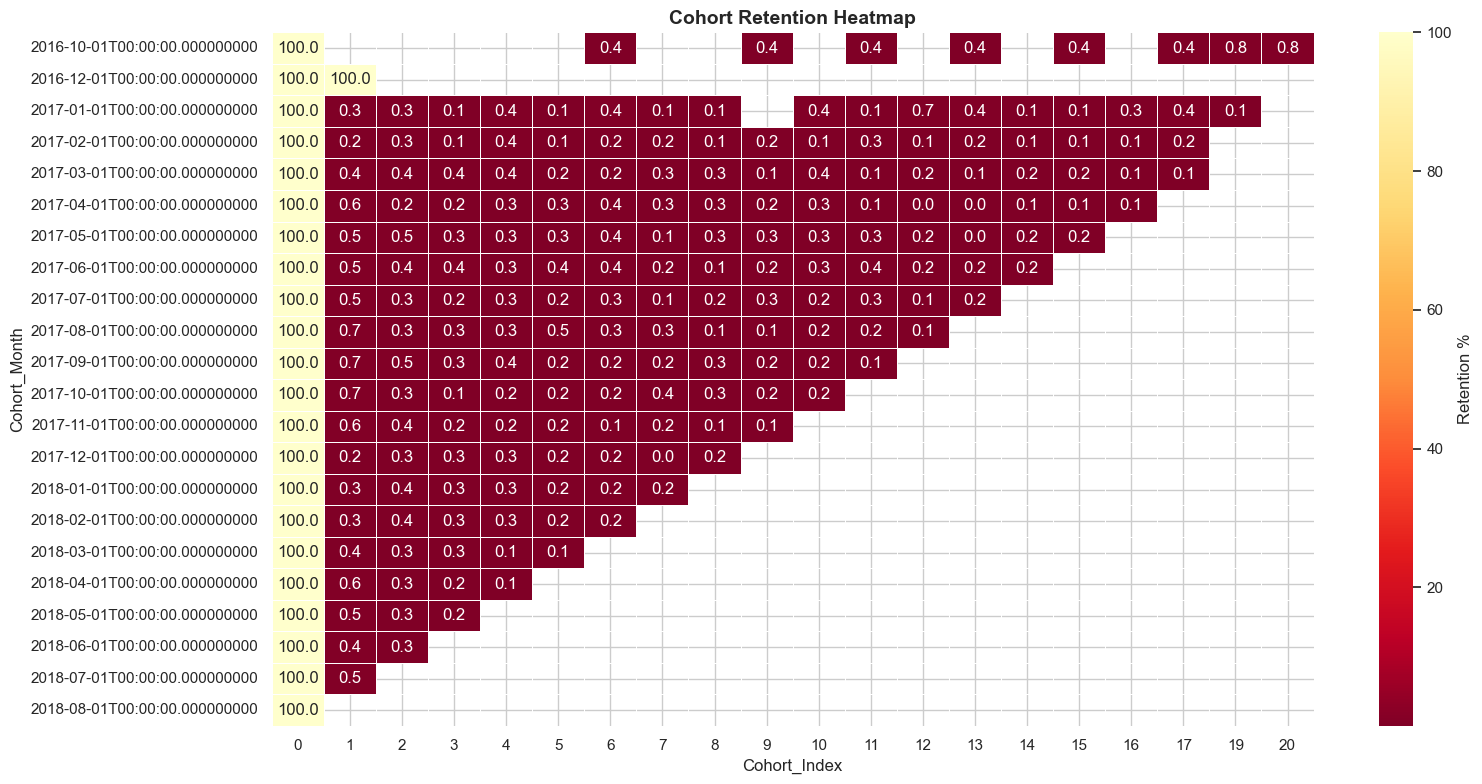

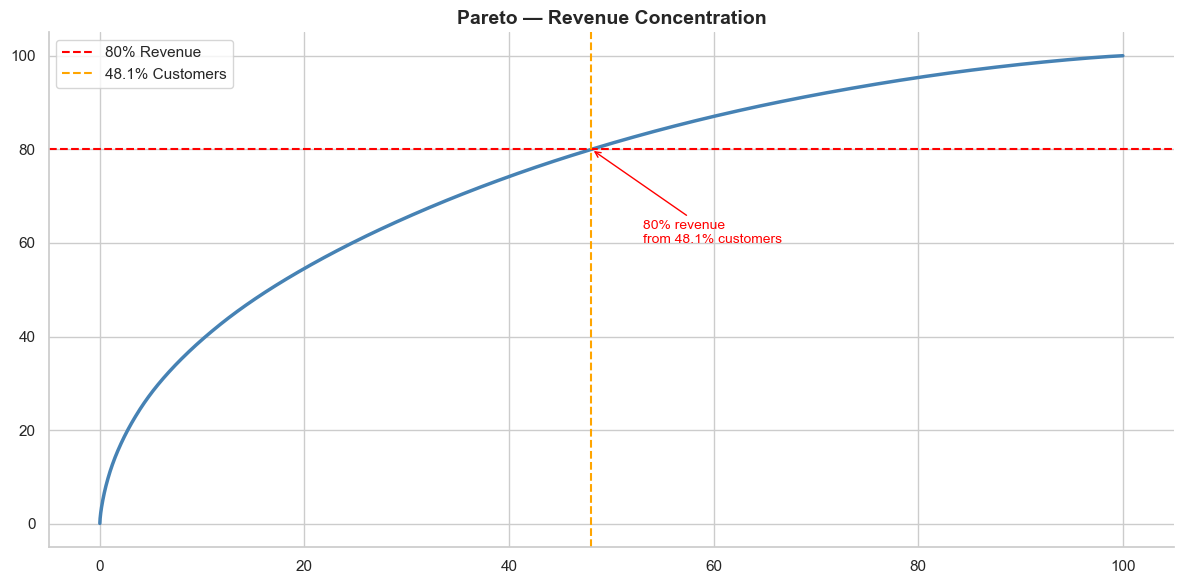

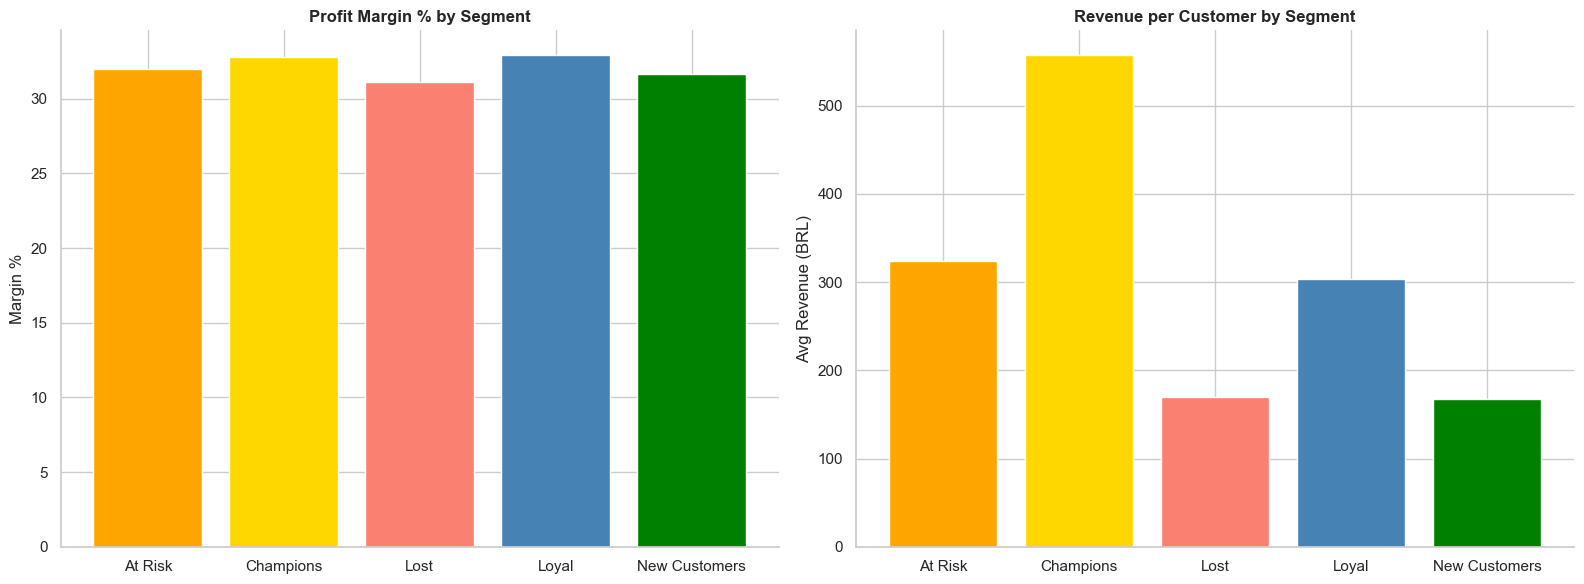

  ✅ Pipeline 5 Done!
  PIPELINE 6 — INTERACTIVE PLOTLY CHARTS


  ✅ Pipeline 6 Done!
  PIPELINE 7 — POWERBI STYLE DASHBOARD


  ✅ Pipeline 7 Done!

🎉 ALL 7 PIPELINES COMPLETE!


In [9]:
# ============================================================
# RUN ALL 7 PIPELINES
# ============================================================

# Pipeline 1 & 2
df                                              = run_pipeline_1(path='./df.csv')
monthly, category, state, rfm, segment, clv, pareto = run_pipeline_2(df)

# Prepare monthly clean
mc = monthly[monthly['total_revenue'] > 0].copy()
mc['purchase_month'] = pd.to_datetime(mc['purchase_month'])

# Pipeline 3 — Static Performance
run_pipeline_3(df, monthly)

# Pipeline 4 — Static Product & Regional
run_pipeline_4(df, category, state)

# Pipeline 5 — Static Customer Intelligence
run_pipeline_5(df, rfm, pareto)

# Pipeline 6 — Interactive Plotly
run_pipeline_6(df, mc, category, rfm)

# Pipeline 7 — PowerBI Dashboard
run_pipeline_7(df, monthly, category, state, rfm)

print("\n🎉 ALL 7 PIPELINES COMPLETE!")